# IMPORT MODULES

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
datagen = ImageDataGenerator(rescale=1./255,validation_split = 0.2)

# LOAD DATASET

In [4]:
train_data = datagen.flow_from_directory(
    'chest_xray/train',
    target_size = (128,128),  # train dataset
    batch_size = 32,
    class_mode = 'categorical'
)

Found 5216 images belonging to 2 classes.


In [5]:
val_data = datagen.flow_from_directory(
    'chest_xray/val',
    target_size = (128,128),   #Validation dataset
    batch_size = 32,
    class_mode = 'categorical'
)

Found 16 images belonging to 2 classes.


In [6]:
test_data = datagen.flow_from_directory(
    'chest_xray/test',
    target_size = (128,128),   #test dataset
    batch_size = 32,
    class_mode = 'categorical'
)

Found 623 images belonging to 2 classes.


# IMAGE SHOW

In [7]:
import matplotlib.pyplot as plt

In [8]:
def show_image(dataset,i):
    images,lables = next(train_data)
    plt.imshow(images[i])
    plt.title(lables[i])
    plt.axis('off')
    plt.show()
 

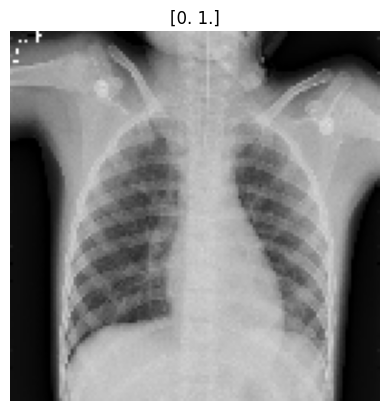

In [9]:
show_image(train_data,31)

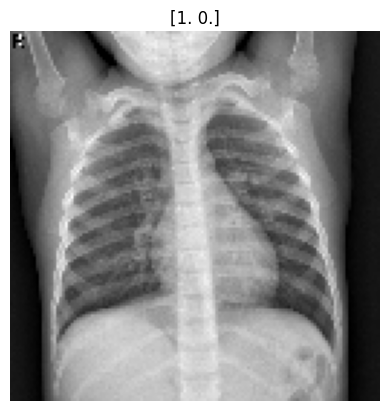

In [10]:
show_image(test_data,2)

In [11]:
train_data.class_indices,test_data.class_indices,val_data.class_indices

({'NORMAL': 0, 'PNEUMONIA': 1},
 {'NORMAL': 0, 'PNEUMONIA': 1},
 {'NORMAL': 0, 'PNEUMONIA': 1})

# DATA AGUMENTATION

In [12]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip = True
)

In [13]:
train_data_set = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical'
)

Found 5216 images belonging to 2 classes.


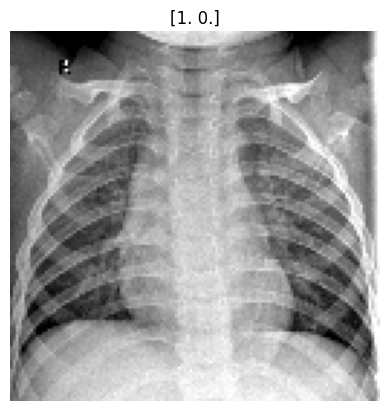

In [14]:
show_image(train_data_set,3)

# BUILDING CNN MODEL

In [15]:
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import optuna
import torch.optim as optim

In [16]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from math import ceil

num_classes = len(train_data_set.class_indices)
model = CNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_loader = DataLoader(
    train_data_set,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
steps_per_epoch = ceil(train_data_set.samples / train_data_set.batch_size)

In [18]:
from tqdm import tqdm

for epoch in range(5):
    model.train()
    running_loss = 0.0
    for step in tqdm(range(steps_per_epoch), desc=f"Epoch {epoch+1}"):
        images, labels = next(train_data_set)

        images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
        labels = torch.tensor(labels)
        labels = torch.argmax(labels, dim=1).long().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/10], Avg Loss: {running_loss/len(train_loader):.4f}")

Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [06:01<00:00,  2.22s/it]


Epoch [1/10], Avg Loss: 14.8417


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [05:57<00:00,  2.19s/it]


Epoch [2/10], Avg Loss: 11.6341


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [07:21<00:00,  2.71s/it]


Epoch [3/10], Avg Loss: 11.0339


Epoch 4: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [06:15<00:00,  2.31s/it]


Epoch [4/10], Avg Loss: 10.2171


Epoch 5: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [06:27<00:00,  2.38s/it]

Epoch [5/10], Avg Loss: 9.1642


# EVALUATION FOR CNN  MODEL

In [19]:
from sklearn.metrics import classification_report , confusion_matrix
import seaborn as sn
import numpy as np
import matplotlib.pyplot as plt

              precision    recall  f1-score   support

      NORMAL       0.52      0.96      0.67       233
   PNEUMONIA       0.95      0.47      0.63       390

    accuracy                           0.65       623
   macro avg       0.73      0.71      0.65       623
weighted avg       0.79      0.65      0.64       623



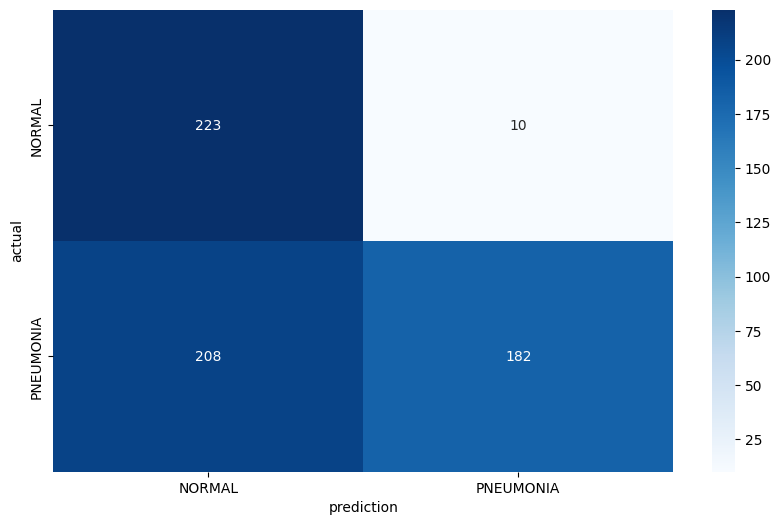

In [20]:
step_val = ceil(test_data.samples/test_data.batch_size)

all_preds = []
all_labels = []

with torch.no_grad():
    for step in range(step_val):

        image , labels = next(test_data)
        
        image = torch.tensor(image).permute(0,3,1,2).float().to(device)
        labels = torch.tensor(labels)
        lables = torch.argmax(labels , dim =1).long()

        outputs = model(image)
        preds = torch.argmax(outputs , dim=1 ).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(lables.numpy())

print(classification_report(all_labels,all_preds,target_names = list(val_data.class_indices.keys())))


cm = confusion_matrix(all_labels,all_preds)
plt.figure(figsize = (10,6))
sn.heatmap(cm, annot = True, cmap = "Blues", fmt = 'd',
           xticklabels = val_data.class_indices.keys(),
           yticklabels = val_data.class_indices.keys())
plt.xlabel("prediction")
plt.ylabel("actual")
plt.show()

# TRANSFER LEARNING

In [21]:
import torchvision.models as models

In [22]:
resnet = models.resnet50(weights= 'IMAGENET1K_V1')
for params in resnet.parameters():

    params.requires_grad = False

resnet.fc = nn.Sequential(
    nn.Linear(resnet.fc.in_features,256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256,num_classes)
)

resnet = resnet.to(device)

optimizer_resnet = torch.optim.Adam(resnet.fc.parameters(),lr=0.001)
criterion = nn.CrossEntropyLoss()

In [23]:
step_per_epoch = ceil(train_data_set.samples/train_data_set.batch_size)


for epoch in range(5):
    resnet.train()
    running_loss = 0.0
    
    for step in tqdm(range(steps_per_epoch), desc=f"Epoch {epoch+1}"):
        images, labels = next(train_data_set)

        images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
        labels = torch.tensor(labels)
        labels = torch.argmax(labels, dim=1).long().to(device)

        optimizer_resnet.zero_grad()

        outputs = resnet(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/10], Avg Loss: {running_loss/len(train_loader):.4f}")

Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [06:16<00:00,  2.31s/it]


Epoch [1/10], Avg Loss: 8.0430


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [06:35<00:00,  2.43s/it]


Epoch [2/10], Avg Loss: 5.5403


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [09:05<00:00,  3.35s/it]


Epoch [3/10], Avg Loss: 5.4899


Epoch 4: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [10:37<00:00,  3.91s/it]


Epoch [4/10], Avg Loss: 5.1106


Epoch 5: 100%|███████████████████████████████████████████████████████████████████████| 163/163 [06:14<00:00,  2.30s/it]

Epoch [5/10], Avg Loss: 5.1494


# EVALUATION FOR TRANSFER LEARNING

              precision    recall  f1-score   support

      NORMAL       0.85      0.62      0.72       233
   PNEUMONIA       0.81      0.94      0.87       390

    accuracy                           0.82       623
   macro avg       0.83      0.78      0.79       623
weighted avg       0.82      0.82      0.81       623



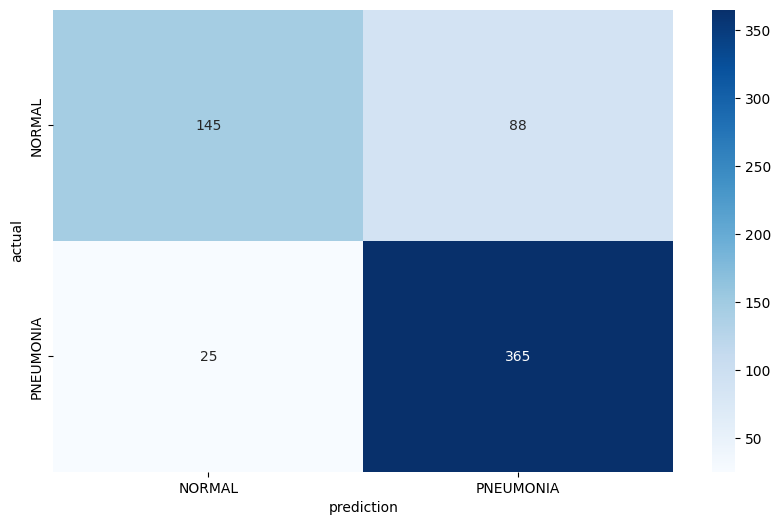

In [24]:
step_val = ceil(test_data.samples/test_data.batch_size)

all_preds = []
all_labels = []

with torch.no_grad():
    for step in range(step_val):

        image , labels = next(test_data)
        
        image = torch.tensor(image).permute(0,3,1,2).float().to(device)
        labels = torch.tensor(labels)
        lables = torch.argmax(labels , dim =1).long()

        outputs = resnet(image)
        preds = torch.argmax(outputs , dim=1 ).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(lables.numpy())

print(classification_report(all_labels,all_preds,target_names = list(val_data.class_indices.keys())))


cm = confusion_matrix(all_labels,all_preds)
plt.figure(figsize = (10,6))
sn.heatmap(cm, annot = True, cmap = "Blues", fmt = 'd',
           xticklabels = val_data.class_indices.keys(),
           yticklabels = val_data.class_indices.keys())
plt.xlabel("prediction")
plt.ylabel("actual")
plt.show()